## Group 2 : Capstone Project 2024 Home Mortgage Disclosure Act (HMDA)

#### Group Members
* Gift Natchapa
* Hazel Mugadza
* Shreyas Kuradagi
* Steven Chu
* Tatenda Kagande
* Oliastic Ngoshi

In [ ]:
import sys
import subprocess

# Check if duckdb is already installed
try:
    import duckdb
    print("Libraries already installed. Skipping installation.")
except ImportError:
    print("Libraries not found. Installing from requirements.txt...")
    # Execute the install command
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

Libraries already installed. Skipping installation.


In [ ]:
import pandas as pd
import duckdb
import os

# Exploratory Data Analysis

In [ ]:
zip_path = "data/2024_lar.zip"
if not os.path.exists(zip_path):
    print("File not found. Downloading...")
    ! wget -P data/ "https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip"
else:
    print("Dataset already exists locally. Skipping download.")

Dataset already exists locally. Skipping download.


In [ ]:
# Define the paths
zip_path = "data/2024_lar.zip"
extracted_path = "data/2024_lar.txt"

# Check if the text file already exists
if not os.path.exists(extracted_path):
    print("Extracting dataset...")
    ! unzip -o {zip_path} -d data/
else:
    print("File is already unzipped. Skipping.")

File is already unzipped. Skipping.


In [ ]:
! head "data/2024_lar.txt" | csvlook

/bin/bash: line 1: csvlook: command not found
head: error writing 'standard output': Broken pipe


In [ ]:
import duckdb

# This creates a persistent 'cache' file on your 32GB storage
con = duckdb.connect('mortgage_cache.db')
# Set the memory limit to 14GB (leaves 2GB for the OS)
con.execute("SET memory_limit='14GB'")

# If the data exceeds 14GB, DuckDB will automatically 
# cache to 'mortgage_cache.db' instead of crashing.
con.execute("SET temp_directory='temp_dir'")

In [ ]:
con = duckdb.connect()
con.execute("DESCRIBE SELECT * FROM read_csv('data/2024_lar.txt', sep='|', header=true)").df()

,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
94,ffiec_msa_md_median_family_income,BIGINT,YES,None,None,None
95,tract_to_msa_income_percentage,DOUBLE,YES,None,None,None
96,tract_owner_occupied_units,BIGINT,YES,None,None,None
97,tract_one_to_four_family_homes,BIGINT,YES,None,None,None


In [ ]:
import psutil
print(f"Total RAM: {psutil.virtual_memory().total / (1024**3):.2f} GB")

Total RAM: 15.62 GB


In [ ]:
data = con.execute("""
    SELECT
        action_taken,
        loan_amount,
        loan_type,
        loan_purpose,
        income,
        debt_to_income_ratio,
        applicant_credit_score_type,
        derived_race,
        derived_sex,
        ffiec_msa_md_median_family_income
    FROM read_csv('data/2024_lar.txt', sep='|', header=true, ignore_errors=true)
""").df()

: 

In [ ]:
data.head().T

,0,1,2,3,4
action_taken,1,3,1,1,1
loan_amount,55000,55000,215000,105000,75000
loan_type,1,1,1,1,1
loan_purpose,2,4,31,2,2
income,167,109,97,87,193
debt_to_income_ratio,20%-<30%,>60%,49,45,44
applicant_credit_score_type,11,11,11,11,9
derived_race,White,White,White,White,White
derived_sex,Joint,Male,Joint,Male,Joint
ffiec_msa_md_median_family_income,110200,101200,110200,110200,87800


In [ ]:
data.shape

(12259129, 10)

In [ ]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['derived_sex'], data['derived_race'])
gender_race_xtab

derived_race,2 or more minority races,American Indian or Alaska Native,Asian,Black or African American,Free Form Text Only,Joint,Native Hawaiian or Other Pacific Islander,Race Not Available,White
derived_sex,,,,,,,,,
Female,10151,27042,158490,415803,673,7398,7406,262805,1611954
Joint,4978,12517,218680,199884,797,222930,6416,337718,2732681
Male,12755,43322,312584,381481,1531,8365,13007,448235,2574908
Sex Not Available,665,837,4747,7285,38,1027,378,2176642,32999


In [ ]:
data['debt_to_income_ratio'].value_counts()

debt_to_income_ratio
NA          4060423
30%-<36%    1097763
20%-<30%    1070945
50%-60%      825624
>60%         621934
<20%         462992
49           400066
44           331702
42           315072
Exempt       286897
43           284027
41           277571
48           268373
40           266770
39           256895
47           251923
45           251386
46           244504
38           239528
37           228027
36           216707
Name: count, dtype: int64

In [ ]:
# Demographic Breakdown (Race)
race_counts = data['derived_race'].value_counts(normalize=True) * 100
print("\nRace Percentages:")
print(race_counts.round(2))


Race Percentages:
derived_race
White                                        56.71
Race Not Available                           26.31
Black or African American                     8.19
Asian                                         5.67
Joint                                         1.96
American Indian or Alaska Native              0.68
2 or more minority races                      0.23
Native Hawaiian or Other Pacific Islander     0.22
Free Form Text Only                           0.02
Name: proportion, dtype: float64


In [ ]:
# 1. Get counts for all unique values
counts = data['derived_sex'].value_counts()
total = counts.sum()

# 2. Loop through every sex type found in the data
for label, count in counts.items():
    percentage = (count / total) * 100
    print(f"{label}: {percentage:.2f}%")

Male: 30.97%
Joint: 30.48%
Female: 20.41%
Sex Not Available: 18.15%


In [ ]:
# 1. First, create an independent copy of your slice 
# This breaks the link to the original 12M row file
data = data.copy() 

# 2. Now perform your mapping safely
# 1: Originated, 2: Approved but not accepted -> Approved (1)
# 3: Application denied -> Denied (0)
data['target'] = data['action_taken'].map({1: 1, 2: 1, 3: 0})

In [ ]:
import numpy as np
# 1. First, filter out zero/negative income to prevent division by zero (Infinity)
# It is best to do this BEFORE creating ratios
data['income'] = pd.to_numeric(data['income'], errors='coerce')

# 2. Numeric transformations
# Use 'income' for the ratio as originally intended
data['loan_to_income_ratio'] = data['loan_amount'] / data['income']
#data['log_loan_amount'] = np.log1p(data['loan_amount'])

# Note: Dividing by (median / 1000) is standard for HMDA 'relative income' metrics
data['relative_income'] = data['income'] / (data['ffiec_msa_md_median_family_income'] / 1000)

# 3. Apply the DTI mapping
dti_map = {'<20%': 15, '20%-<30%': 25, '30%-<36%': 33, '50%-60%': 55}

# Map the strings, then fill remaining values by attempting to convert them to numbers
data['dti_numeric'] = data['debt_to_income_ratio'].map(dti_map).fillna(
    pd.to_numeric(data['debt_to_income_ratio'], errors='coerce')
)

# 4. Final Clean up
# Replace any unexpected 'inf' with NaN and drop them
data = data.replace([np.inf, -np.inf], np.nan)

In [ ]:
data.head().T

,0,1,2,3,4
action_taken,1,3,1,1,1
loan_amount,55000,55000,215000,105000,75000
loan_type,1,1,1,1,1
loan_purpose,2,4,31,2,2
income,167.0,109.0,97.0,87.0,193.0
debt_to_income_ratio,20%-<30%,>60%,49,45,44
applicant_credit_score_type,11,11,11,11,9
derived_race,White,White,White,White,White
derived_sex,Joint,Male,Joint,Male,Joint
ffiec_msa_md_median_family_income,110200,101200,110200,110200,87800


In [ ]:
data["dti_numeric"] = data["dti_numeric"].astype("object")

mask = data["debt_to_income_ratio"].str.lower() == "exempt"
data.loc[mask, "dti_numeric"] = "exempt"

In [ ]:
data.head().T

,0,1,2,3,4
action_taken,1,3,1,1,1
loan_amount,55000,55000,215000,105000,75000
loan_type,1,1,1,1,1
loan_purpose,2,4,31,2,2
income,167.0,109.0,97.0,87.0,193.0
debt_to_income_ratio,20%-<30%,>60%,49,45,44
applicant_credit_score_type,11,11,11,11,9
derived_race,White,White,White,White,White
derived_sex,Joint,Male,Joint,Male,Joint
ffiec_msa_md_median_family_income,110200,101200,110200,110200,87800


In [ ]:
def dti_risk(num):
    if num == "exempt":
        return "exempt"
    if num < 36:
        return "low_risk"
    if 36 <= num <= 43:
        return "mid_risk"
    if 44 <= num <= 50:
        return "high_risk"
    if num > 50:
        return "extreme_risk"

data['dti_category'] = data['dti_numeric'].apply(dti_risk)

In [ ]:
# Drop the original categorical columns that have been transformed
cols_to_drop = ['loan_amount', 'income', 'action_taken','debt_to_income_ratio','loan_to_income_ratio','dti_numeric']
data = data.drop(columns=cols_to_drop)

In [ ]:
data.sample(8).T

,8064328,9867261,3137493,5846316,5981509,4714901,9289471,3122377
loan_type,1,1,1,1,1,1,1,2
loan_purpose,4,4,1,1,4,1,31,1
applicant_credit_score_type,9,9,9,2,1,1,9,3
derived_race,White,White,White,Race Not Available,White,Asian,Race Not Available,White
derived_sex,Male,Joint,Female,Joint,Female,Male,Joint,Joint
ffiec_msa_md_median_family_income,101800,79700,84300,123700,114000,76600,97500,104500
target,NaN,NaN,NaN,1.0,1.0,1.0,NaN,1.0
relative_income,1.168959,1.668758,NaN,2.457559,1.22807,1.148825,1.05641,0.956938
dti_category,NaN,NaN,NaN,low_risk,low_risk,mid_risk,NaN,high_risk


In [ ]:
# Create a mapping dictionary for formal terminology
race_map = {
    'Black or African American': 'African-American',
    'White': 'Caucasian',
    'Asian': 'Asian',
    'American Indian or Alaska Native': 'Indigenous',
    'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
    '2 or more minority races': 'Multiracial',
    'Joint': 'Joint',
    'Free Form Text Only': 'Other'
}

# Apply the mapping and group "Race Not Available" as NaN to drop or impute
data['race'] = data['derived_race'].map(race_map)

# Drop the original string race column
data = data.drop(columns=['derived_race'])

# Optional: Group smaller categories into 'Other' if they are under a 1% threshold
# to improve model stability
minority_groups = ['Indigenous', 'Pacific Islander', 'Multiracial', 'Other']
data['race'] = data['race'].replace(minority_groups, 'Minority')

In [ ]:
data.head().T

,0,1,2,3,4
loan_type,1,1,1,1,1
loan_purpose,2,4,31,2,2
applicant_credit_score_type,11,11,11,11,9
derived_sex,Joint,Male,Joint,Male,Joint
ffiec_msa_md_median_family_income,110200,101200,110200,110200,87800
target,1.0,0.0,1.0,1.0,1.0
relative_income,1.515426,1.077075,0.880218,0.789474,2.198178
dti_category,low_risk,NaN,high_risk,high_risk,high_risk
race,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian


In [ ]:
data.isnull().sum()

loan_type                                  0
loan_purpose                               0
applicant_credit_score_type                0
derived_sex                                0
ffiec_msa_md_median_family_income          0
target                               3597352
relative_income                      2041196
dti_category                         4682357
race                                 3225400
dtype: int64

In [ ]:
# Drop all rows containing any null values
data = data.dropna()
data.isnull().sum()

loan_type                            0
loan_purpose                         0
applicant_credit_score_type          0
derived_sex                          0
ffiec_msa_md_median_family_income    0
target                               0
relative_income                      0
dti_category                         0
race                                 0
dtype: int64

In [ ]:
data.shape

(6174186, 9)

In [ ]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['derived_sex'], data['race'])
gender_race_xtab

race,African-American,Asian,Caucasian,Joint,Minority
derived_sex,,,,,
Female,252712,98596,1089917,5064,27042
Joint,128306,149304,2007929,156341,15893
Male,226729,199409,1741593,5767,42486
Sex Not Available,3467,2720,19200,661,1050


In [ ]:
# 1. Get counts for all unique values
counts = data['race'].value_counts()
total = counts.sum()

# 2. Loop through every sex type found in the data
for label, count in counts.items():
    percentage = (count / total) * 100
    print(f"{label}: {percentage:.2f}%")

Caucasian: 78.69%
African-American: 9.90%
Asian: 7.29%
Joint: 2.72%
Minority: 1.40%


In [ ]:
# 1. Remove rows where 'Sex Not Available' is recorded
data = data[data['derived_sex'] != 'Sex Not Available'].copy()
# 2. Rename the column to 'gender'
data = data.rename(columns={'derived_sex': 'gender'})

In [ ]:
# Gender vs Race cross-tabulation (matches xtabs in R)
gender_race_xtab = pd.crosstab(data['gender'], data['race'])
gender_race_xtab

race,African-American,Asian,Caucasian,Joint,Minority
gender,,,,,
Female,252712,98596,1089917,5064,27042
Joint,128306,149304,2007929,156341,15893
Male,226729,199409,1741593,5767,42486


In [ ]:
data.shape

(6147088, 9)

In [ ]:
data.head().T

,0,2,3,4,5
loan_type,1,1,1,1,1
loan_purpose,2,31,2,2,31
applicant_credit_score_type,11,11,11,9,11
gender,Joint,Joint,Male,Joint,Female
ffiec_msa_md_median_family_income,110200,110200,110200,87800,115400
target,1.0,1.0,1.0,1.0,1.0
relative_income,1.515426,0.880218,0.789474,2.198178,2.348354
dti_category,low_risk,high_risk,high_risk,high_risk,mid_risk
race,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian


In [ ]:
column_list = data.columns.tolist()
print(column_list)

['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'gender', 'ffiec_msa_md_median_family_income', 'target', 'relative_income', 'dti_category', 'race']


In [ ]:
# 1. Check the specific unique values
print("Unique values in target:", data['target'].unique())
# 2. Check the count and distribution of each class
print("\nClass Distribution:")
print(data['target'].value_counts())
# 3. Check the percentage distribution
print("\nPercentage Distribution:")
print(data['target'].value_counts(normalize=True) * 100)

Unique values in target: [1. 0.]

Class Distribution:
target
1.0    5085319
0.0    1061769
Name: count, dtype: int64

Percentage Distribution:
target
1.0    82.727285
0.0    17.272715
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the correct HMDA column name
score_col = 'applicant_credit_score_type' 

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot for African applicants
sns.countplot(data=data[data['race'] == 'African-American'], x=score_col, ax=axes[0], color='steelblue')
axes[0].set_title("African Applicant's Credit Score Type")

# Plot for Caucasian applicants
sns.countplot(data=data[data['race'] == 'Caucasian'], x=score_col, ax=axes[1], color='steelblue')
axes[1].set_title("Caucasian Applicant's Credit Score Type")

plt.tight_layout()
plt.show()

: 

# Model Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=['target','race','gender'])
y = data['target']

# Standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X.columns.tolist())

['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'ffiec_msa_md_median_family_income', 'relative_income', 'dti_category']


In [ ]:
# 1. Define 'features' by dropping the target column
# This ensures you don't include the answer (target) in your input data
features = data.drop(columns=['target', 'race', 'gender'])

# 2. Select only columns with numeric data types
# FIX: Call select_dtypes directly on the 'features' DataFrame
numeric_features = features.select_dtypes(include=['number']).columns.tolist()

# 3. Select only columns with categorical/string data types
# FIX: Call select_dtypes directly on the 'features' DataFrame
categorical_features = features.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

Numeric Features: ['loan_type', 'loan_purpose', 'applicant_credit_score_type', 'ffiec_msa_md_median_family_income', 'relative_income']
Categorical Features: ['dti_category']


In [ ]:
from sklearn. preprocessing import StandardScaler, OneHotEncoder
from sklearn. compose import ColumnTransformer

preprocessor = ColumnTransformer ([("num", StandardScaler(), numeric_features),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),])

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Calculate the exact imbalance ratio
# XGBoost's scale_pos_weight affects the POSITIVE class (usually 1 / Approved)
# If Approvals heavily outnumber Denials, this fraction will correctly penalize over-approving.
num_denied = (y_train == 0).sum()
num_approved = (y_train == 1).sum()
imbalance_ratio = num_denied / num_approved 

# Create the XGBoost Pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor), # Using your existing ColumnTransformer
    ("classifier", XGBClassifier(
        scale_pos_weight=imbalance_ratio,
        random_state=42,
        n_jobs=-1 # Uses all CPU cores to run much faster
    ))
])

# Define a small search grid for tuning
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1, 0.2]
}

# Set up the Random Search, optimizing specifically for F1-Score
print("Starting Hyperparameter Tuning...")
search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_grid,
    n_iter=5, # Number of random combinations to try
    scoring='f1', # Forces the model to balance Precision and Recall
    cv=3, 
    verbose=1,
    random_state=42
)

# Fit the search to find the best model
search.fit(X_train, y_train)
best_model = search.best_estimator_

print(f"\nBest Parameters Found: {search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters Found: {'classifier__n_estimators': 200, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.05}


In [ ]:
# 1. Add the predictions back to the DataFrame
data['pred_class'] = best_model.predict(X)

# 2. Create the Confusion Matrix
# 'target' is the Actual outcome, 'pred_class' is what your model predicted
overall_cm = pd.crosstab(
    data['pred_class'],
    data['target'],
    rownames=['Predicted'],
    colnames=['Actual']
)

print("── Overall Confusion Matrix (Approved=1, Denied=0) ──────────────────")
print(overall_cm)

# 3. Extract values
# We use the integer keys (1 and 0) which match your binary target
# TP: Predicted Approved (1), Actually Approved (1)
# TN: Predicted Denied (0), Actually Denied (0)
tp = overall_cm.loc[1, 1]
tn = overall_cm.loc[0, 0]
fp = overall_cm.loc[1, 0]
fn = overall_cm.loc[0, 1]
n  = overall_cm.values.sum()

# 4. Print metrics formatted for your Final Report
print(f"\nAccuracy  : {(tp + tn) / n:.3f}")
print(f"Precision : {tp / (tp + fp):.3f}")  # Ability to find only true approvals
print(f"Recall    : {tp / (tp + fn):.3f}")  # Ability to find all true approvals
print(f"FPR       : {fp / (fp + tn):.3f}")  # False Positive Rate (Unfair approval)
print(f"FNR       : {fn / (fn + tp):.3f}")  # False Negative Rate (Unfair denial)

── Overall Confusion Matrix (Approved=1, Denied=0) ──────────────────
Actual        0.0      1.0
Predicted                 
0          757008  1462301
1          304756  3623010

Accuracy  : 0.713
Precision : 0.922
Recall    : 0.712
FPR       : 0.287
FNR       : 0.288


# Evaluation
## Receiver Operating Characteristic - Area Under the Curve

A performance metric for binary classification problems. It measures a model's ability to differentiate between classes (e.g., positive vs. negative) across various thresholds by plotting the True Positive Rate (sensitivity) against the False Positive Rate ( 1-Specificity)

ROC AUC Score: 0.7832


<Figure size 800x600 with 0 Axes>

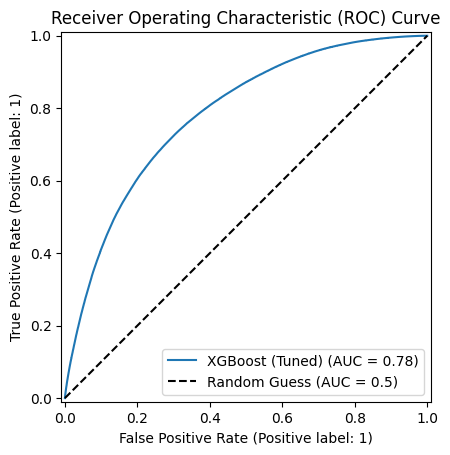

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class (class 1)
# The [:, 1] extracts the probabilities specifically for the 'Approved' class
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 2. Calculate and print the exact ROC AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {auc_score:.4f}")

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
# RocCurveDisplay is the modern scikit-learn way to plot this directly from the estimator
display = RocCurveDisplay.from_estimator(best_model, X_test, y_test, name="XGBoost (Tuned)")

# Add a diagonal line representing a random guess baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# 1. Create the Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor), # Re-using your exact column transformer
    ("classifier", LogisticRegression(
        class_weight='balanced', # Handles the 80/20 class imbalance
        random_state=42,
        max_iter=1000 # Increased to ensure convergence 
    ))
])

# 2. Train the baseline model
print("Training Logistic Regression Baseline...")
lr_pipeline.fit(X_train, y_train)

# 3. Make predictions
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# 4. Calculate Baseline Metrics
lr_f1 = f1_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

# 5. Predict with your existing best_model (XGBoost) for direct comparison
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

xgb_f1 = f1_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# 6. Print the Comparison
print("\n─── Model Comparison ───")
print(f"Logistic Regression (Baseline):")
print(f"  F1-Score : {lr_f1:.4f}")
print(f"  ROC-AUC  : {lr_auc:.4f}")

print(f"\nXGBoost:")
print(f"  F1-Score : {xgb_f1:.4f}")
print(f"  ROC-AUC  : {xgb_auc:.4f}")

# Lift calculations
print(f"\nPerformance Lift from XGBoost:")
print(f"  F1 Lift  : +{(xgb_f1 - lr_f1):.4f}")
print(f"  AUC Lift : +{(xgb_auc - lr_auc):.4f}")

Training Logistic Regression Baseline...

─── Model Comparison ───
Logistic Regression (Baseline):
  F1-Score : 0.7725
  ROC-AUC  : 0.6649

XGBoost (Tuned):
  F1-Score : 0.8039
  ROC-AUC  : 0.7832

Performance Lift from XGBoost:
  F1 Lift  : +0.0314
  AUC Lift : +0.1183


### Fairness Audit

In [ ]:
print("\n\n── Fairness Audit: Confusion Matrix by Race ──────────────────────────\n")

# 1. Calculate base counts and metrics grouped by Race
# We assume 'target' and 'pred_class' are both integers (0 and 1)
race_metrics = (
    data.assign(
        actual=lambda x: x['target'].astype(int),
        pred=lambda x: x['pred_class'].astype(int)
    )
    .assign(
        is_TP=lambda x: (x['pred'] == 1) & (x['actual'] == 1), # True Approval
        is_TN=lambda x: (x['pred'] == 0) & (x['actual'] == 0), # True Denial
        is_FP=lambda x: (x['pred'] == 1) & (x['actual'] == 0), # False Approval
        is_FN=lambda x: (x['pred'] == 0) & (x['actual'] == 1)  # False Denial (The "Unfair" Denial)
    )
    .groupby('race')
    .agg(
        n=('race', 'size'),
        TP=('is_TP', 'sum'),
        TN=('is_TN', 'sum'),
        FP=('is_FP', 'sum'),
        FN=('is_FN', 'sum')
    )
    .assign(
        Accuracy=lambda x: ((x['TP'] + x['TN']) / x['n']).round(3),
        Precision=lambda x: (x['TP'] / (x['TP'] + x['FP'])).round(3),
        Recall=lambda x: (x['TP'] / (x['TP'] + x['FN'])).round(3),
        FPR=lambda x: (x['FP'] / (x['FP'] + x['TN'])).round(3), # False Positive Rate
        FNR=lambda x: (x['FN'] / (x['FN'] + x['TP'])).round(3)  # False Negative Rate
    )
    .sort_values(by='n', ascending=False)
    .reset_index()
)

# Display the table
print(race_metrics.to_string(index=False))

# 2. Print a quick Disparate Impact check
try:
    white_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]
    black_fnr = race_metrics.loc[race_metrics['race'] == 'African-American', 'FNR'].values[0]
    fnr_ratio = black_fnr / white_fnr if white_fnr > 0 else 0
    
    print(f"\n--- Equality of Opportunity Check ---")
    print(f"African-American FNR: {black_fnr}")
    print(f"Caucasian FNR: {white_fnr}")
    print(f"FNR Ratio (Black/White): {fnr_ratio:.2f}x")
    print("Interpretation: A ratio > 1.0 means Black applicants are 'falsely denied' more often.")
except:
    print("\nNote: Ensure 'African' and 'Caucasian' labels match your race column values.")



── Fairness Audit: Confusion Matrix by Race ──────────────────────────

            race       n      TP     TN     FP      FN  Accuracy  Precision  Recall   FPR   FNR
       Caucasian 4839432 2853092 555437 221580 1209323     0.704      0.928   0.702 0.285 0.298
African-American  607746  292506 126751  45548  142941     0.690      0.865   0.672 0.264 0.328
           Asian  447307  323069  40091  23517   60630     0.812      0.932   0.842 0.370 0.158
           Joint  167171  112301  16381   8428   30061     0.770      0.930   0.789 0.340 0.211
        Minority   85419   42042  18348   5683   19346     0.707      0.881   0.685 0.236 0.315

--- Equality of Opportunity Check ---
African-American FNR: 0.328
Caucasian FNR: 0.298
FNR Ratio (Black/White): 1.10x
Interpretation: A ratio > 1.0 means Black applicants are 'falsely denied' more often.


### Compare model performance by race

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, groups, group_name="race"):
    results = []
    X_ = X.copy()
    
    # Add the evaluation columns
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]
    
    # Temporarily add the protected attribute just for this analysis dataframe
    # Using .values ensures we don't get misaligned index errors if indices differ slightly
    X_[group_name] = groups.values 

    for group, gdf in X_.groupby(group_name, observed=False):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()
        
        results.append({
            group_name : group,
            "n" : len(gdf),
            "accuracy" : round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR" : round(fp / (fp + tn), 3),
            "FNR" : round(fn / (fn + tp), 3),
            "AUC" : round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })
        
    return pd.DataFrame(results).sort_values("n", ascending=False)

In [ ]:
# Assuming 'original_df' is your full dataframe before you dropped 'race'
# We use X_test.index to grab the exact rows that ended up in the test set
race_test_labels = data.loc[X_test.index, 'race']

# Now pass those labels into your new 'groups' parameter
print(group_metrics(
    pipeline=best_model, 
    X=X_test, 
    y=y_test, 
    groups=race_test_labels, 
    group_name="race"
))

               race       n  accuracy    FPR    FNR    AUC
2         Caucasian  967712     0.704  0.287  0.298  0.779
0  African-American  122063     0.691  0.262  0.328  0.773
1             Asian   89240     0.812  0.373  0.158  0.800
3             Joint   33194     0.770  0.336  0.211  0.795
4          Minority   17206     0.706  0.239  0.315  0.797


### LIME explanations: Black vs White defendant

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# --- 1. EXTRACT THE FITTED PREPROCESSOR ---
fitted_preprocessor = best_model.named_steps["preprocessor"] 

# Transform training data using the FITTED preprocessor
X_train_sample = X_train.sample(5000, random_state=42)
X_train_enc = fitted_preprocessor.transform(X_train_sample)

if hasattr(X_train_enc, "toarray"): 
    X_train_enc = X_train_enc.toarray()

# --- 2. RECONSTRUCT FEATURE NAMES ---
# Use the fitted_preprocessor to get the feature names
feature_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# Initialize the Explainer (No changes needed here)
explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feature_names,
    class_names=["Denied", "Approved"], 
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# --- Selection Logic for Comparison (CORRECTED) ---
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = best_model.predict_proba(X_test)[:, 1]

# BRING BACK THE RACE COLUMN FROM THE ORIGINAL DATAFRAME
# Replace 'original_df' with whatever your starting dataframe was named
X_test_copy["race"] = data.loc[X_test.index, "race"]

# Now your filtering will work perfectly
african_df = X_test_copy[X_test_copy['race'] == 'African-American'].sort_values("pred_prob")
caucasian_df = X_test_copy[X_test_copy['race'] == 'Caucasian'].sort_values("pred_prob")

african_idx = african_df.index[len(african_df) // 2]
caucasian_idx = caucasian_df.index[len(caucasian_df) // 2]

# Generate LIME explanations
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    print(f"\n--- {label} (Index: {idx}) ---")

    # --- 3. TRANSFORM TEST ROW ---
    # Use the FITTED preprocessor here as well
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])
    
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()

    # explain_instance needs the raw classifier because row_enc is already preprocessed
    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=best_model.named_steps["classifier"].predict_proba,
        num_features=6
    )

    # Output the top features contributing to the decision
    for feat, weight in exp.as_list():
        print(f"{feat:<40} {weight:+.4f}")


--- African Applicant (Index: 2812860) ---
dti_category_extreme_risk <= 0.00        +0.2517
loan_type <= -0.45                       +0.0762
loan_purpose > -0.34                     +0.0759
dti_category_high_risk > 0.00            -0.0482
ffiec_msa_md_median_family_income > 0.46 +0.0354
dti_category_mid_risk <= 0.00            -0.0168

--- Caucasian Applicant (Index: 5591286) ---
dti_category_extreme_risk > 0.00         -0.2593
relative_income <= -0.01                 -0.0781
loan_type > -0.45                        -0.0773
loan_purpose <= -0.58                    -0.0647
dti_category_high_risk <= 0.00           +0.0451
-0.66 < ffiec_msa_md_median_family_income <= -0.09 +0.0183


In [ ]:
from IPython.display import display, HTML

# 1. Update labels to match your HMDA terminology (African/Caucasian)
# Ensure african_idx and caucasian_idx were successfully defined in the previous step
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    print(f"\n--- {label} (Index: {idx}) ---")

    # 2. Transform the specific row using your FITTED preprocessor
    # We use .loc[[idx]] to keep it as a DataFrame, which preprocessor expects
    row_enc = best_model.named_steps["preprocessor"].transform(X_test.loc[[idx]])
    
    # Convert sparse output from OneHotEncoder to dense for LIME
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()

    # 3. Generate the explanation
    # predict_fn should be the classifier's probability function 
    # because row_enc is already in the 'processed' numeric state
    exp = explainer.explain_instance(
        data_row=row_enc[0],
        predict_fn=best_model.named_steps["classifier"].predict_proba,
        num_features=10 # Increased to see more mortgage factors like DTI and Loan Amount
    )

    # 4. Display the interactive visualization
    print(f"LIME Explanation for {label}")
    display(HTML(exp.as_html()))


--- African Applicant (Index: 2812860) ---
LIME Explanation for African Applicant



--- Caucasian Applicant (Index: 5591286) ---
LIME Explanation for Caucasian Applicant


#### SHAP beeswarm and waterfall:  Black vs White

Generating Global Summary Plot...


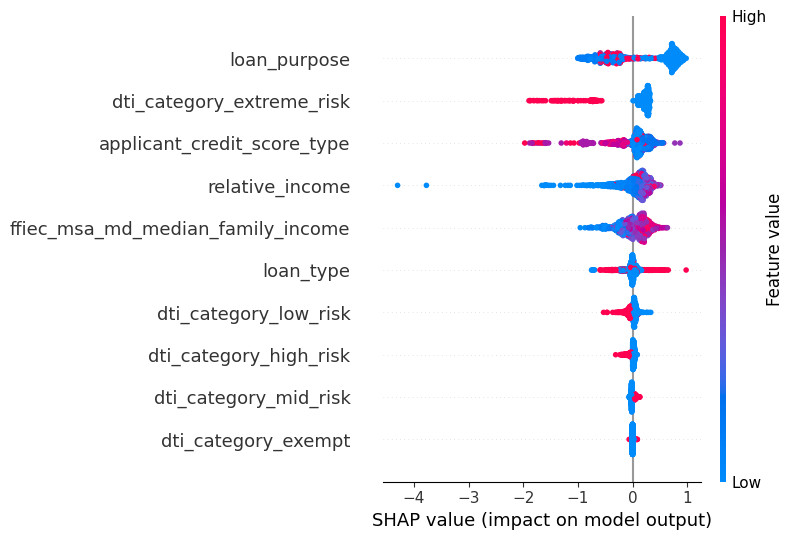


--- SHAP Waterfall: African Applicant (Index: 2812860) ---


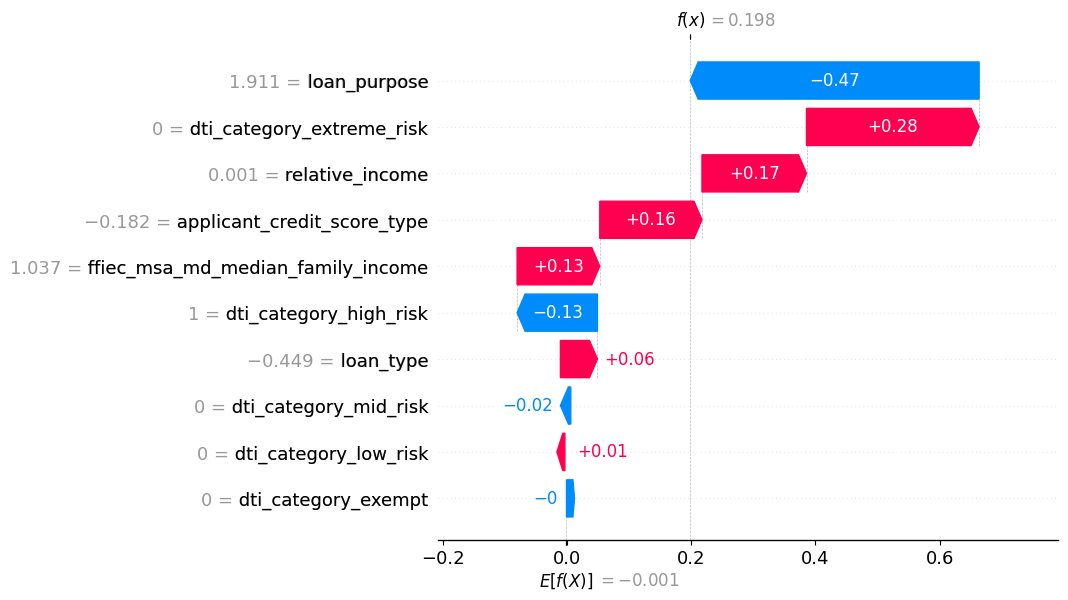


--- SHAP Waterfall: Caucasian Applicant (Index: 5591286) ---


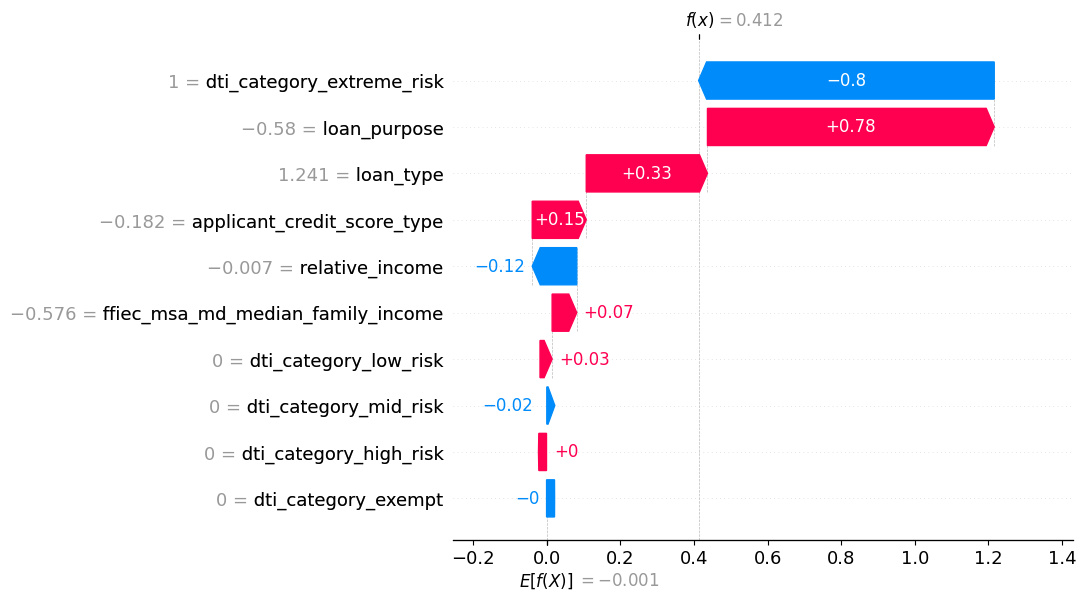

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# --- 1. EXTRACT THE FITTED PREPROCESSOR ---
fitted_preprocessor = best_model.named_steps["preprocessor"]

# Sample the test data for global explanation
X_test_sample = X_test.sample(1000, random_state=42)
X_test_enc = fitted_preprocessor.transform(X_test_sample)

# --- 2. HANDLE SPARSE MATRICES ---
# TreeExplainer prefers dense arrays
if hasattr(X_test_enc, "toarray"):
    X_test_enc = X_test_enc.toarray()

# 3. Reconstruct Feature Names from the ColumnTransformer
feat_names = numeric_features + list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# 4. Initialize TreeExplainer
# TreeExplainer is much faster than KernelExplainer for GBT models.
explainer_shap = shap.TreeExplainer(best_model.named_steps["classifier"])

# 5. Calculate SHAP values
shap_values = explainer_shap.shap_values(X_test_enc)

# 6. Global Summary (Beeswarm) Plot
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

print("Generating Global Summary Plot...")
shap.summary_plot(shap_to_plot, X_test_enc, feature_names=feat_names)

# 7. Individual Waterfall Plots (Local Explanations)
for label, idx in [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]:
    # Transform the specific row using the FITTED preprocessor
    row_enc = fitted_preprocessor.transform(X_test.loc[[idx]])
    
    # Ensure it's dense
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()
        
    row_shap = explainer_shap.shap_values(row_enc)
    
    # Handle SHAP output format consistency
    if isinstance(row_shap, list):
        row_values = row_shap[1][0]
        base_val = explainer_shap.expected_value[1]
    else:
        row_values = row_shap[0]
        base_val = explainer_shap.expected_value

    # Create the Explanation object (required for waterfall_plot)
    explanation = shap.Explanation(
        values=row_values, 
        base_values=base_val, 
        data=row_enc[0], 
        feature_names=feat_names
    )
    
    print(f"\n--- SHAP Waterfall: {label} (Index: {idx}) ---")
    shap.waterfall_plot(explanation, max_display=10)

### Counterfactuals with DiCE: Black vs White

In [ ]:
import dice_ml
from dice_ml import Dice

# 1. Define the outcome name as a string
# In your HMDA dataset, the target column is usually named 'target'
outcome_column_name = 'target' 

# 2. Setup DiCE Data
# We use a sample for dice_data because DiCE is computationally heavy
# and doesn't need all 6 million rows to understand the feature ranges
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1).sample(5000, random_state=42),
    continuous_features=numeric_features,
    outcome_name=outcome_column_name
)

# 3. Setup DiCE Model
# Note: Use the whole pipeline (best_model) so DiCE understands the transformations
dice_model = dice_ml.Model(
    model=best_model, 
    backend="sklearn", 
    model_type="classifier"
)

# 4. Initialize DiCE
# 'random' is faster for large feature sets
exp_dice = Dice(dice_data, dice_model, method="random")

# 5. Generate Counterfactuals for your African Applicant
# This shows: "If your income was X higher, you would have been approved"
print(f"Generating counterfactuals for Index: {african_idx}")
query_instance = X_test.loc[[african_idx]]
dice_exp = exp_dice.generate_counterfactuals(
    query_instance, 
    total_CFs=3, 
    desired_class="opposite"
)

print(f"Generating counterfactuals for Index: {caucasian_idx}")
query_instance = X_test.loc[[caucasian_idx]]
dice_exp = exp_dice.generate_counterfactuals(
    query_instance, 
    total_CFs=3, 
    desired_class="opposite"
)

# Visualize the counterfactuals
dice_exp.visualize_as_dataframe(show_only_changes=True)

Generating counterfactuals for Index: 2812860


100%|██████████| 1/1 [00:00<00:00, 21.26it/s]


Generating counterfactuals for Index: 5591286


100%|██████████| 1/1 [00:00<00:00, 29.20it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,87700,0.684151,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,-,30,-,-,-,-,0
1,-,-,463,-,-,-,0
2,-,-,-,-,28.3,-,0


In [ ]:
# 2. Define the cases
test_cases = [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]

# Ensure target is an integer
data['target'] = data['target'].astype(int)

for label, idx in test_cases:
    print(f"\n--- Counterfactual for: {label}, Index: {idx} ---")
    query_instance = X_test.loc[[idx]]
    
    # Check the actual prediction first
    current_pred = best_model.predict(query_instance)[0]
    print(f"Current Model Prediction: {current_pred}")
    
    try:
        # Attempt 1: Strict features
        dice_exp = exp_dice.generate_counterfactuals(
            query_instance, 
            total_CFs=2, 
            desired_class="opposite", # Automatically looks for the flipped outcome
            features_to_vary=['loan_to_income_ratio', 'dti_category', 'relative_income']
        )
        print("Success! Found counterfactuals within restricted features.")
        dice_exp.visualize_as_dataframe(show_only_changes=True)
        
    except Exception as e:
        print("Could not find a valid counterfactual by only changing DTI and Income.")
        print("Attempting to find a counterfactual by allowing ALL features to vary...")
        
        try:
            # Attempt 2: Allow all features to vary to see what it actually takes
            dice_exp_fallback = exp_dice.generate_counterfactuals(
                query_instance, 
                total_CFs=2, 
                desired_class="opposite" 
            )
            dice_exp_fallback.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"Even with all features varied, no counterfactual was found. Error: {e}")


--- Counterfactual for: African Applicant, Index: 2812860 ---
Current Model Prediction: 1


  0%|          | 0/1 [00:00<?, ?it/s]


Could not find a valid counterfactual by only changing DTI and Income.
Attempting to find a counterfactual by allowing ALL features to vary...


100%|██████████| 1/1 [00:00<00:00, 24.15it/s]

Query instance (original outcome : 1)


...

100%|██████████| 1/1 [00:00<00:00, 31.40it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,87700,0.684151,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,-,11,-,-,58.3,-,0
1,-,-,41,-,-,-,0


In [ ]:
# 1. Setup Data - Ensure categorical features are explicitly defined
# DiCE needs to know 'dti_category' is categorical to sample valid categories
d_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1).sample(5000, random_state=42),
    continuous_features=numeric_features, 
    categorical_features=['dti_category'], # <-- CRITICAL FIX ADDED
    outcome_name='target' 
)

# Switch to 'genetic' method - much better at finding narrow approval boundaries
d_model = dice_ml.Model(model=best_model, backend="sklearn")
exp_dice = Dice(d_data, d_model, method="genetic") # <-- CRITICAL FIX ADDED

# 2. Define the cases
test_cases = [("African Applicant", african_idx), ("Caucasian Applicant", caucasian_idx)]

# Ensure target is an integer
data['target'] = data['target'].astype(int)

for label, idx in test_cases:
    print(f"\n--- Counterfactual for: {label}, Index: {idx} ---")
    query_instance = X_test.loc[[idx]]
    
    # Print the current prediction so you know what you are trying to flip
    current_pred = best_model.predict(query_instance)[0]
    print(f"Current Model Prediction: {current_pred}")
    
    try:
        # Attempt 1: Strict features (Only DTI, Loan-to-Income, Relative Income)
        dice_exp = exp_dice.generate_counterfactuals(
            query_instance, 
            total_CFs=2, 
            desired_class="opposite", 
            features_to_vary=['loan_to_income_ratio', 'dti_category', 'relative_income']
        )
        print("Success! Found counterfactuals within restricted features.")
        dice_exp.visualize_as_dataframe(show_only_changes=True)
        
    except Exception as e:
        # Fallback if changing those 3 features isn't enough to secure an approval
        print("\nCould not find a valid counterfactual by only changing DTI and Income.")
        print("Attempting to find a counterfactual by allowing ALL features to vary...")
        
        try:
            # Attempt 2: Allow all features to vary to see what it actually takes
            dice_exp_fallback = exp_dice.generate_counterfactuals(
                query_instance, 
                total_CFs=2, 
                desired_class="opposite" 
            )
            dice_exp_fallback.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"Even with all features varied, no counterfactual was found. Error: {e}")


--- Counterfactual for: African Applicant, Index: 2812860 ---
Current Model Prediction: 1


  0%|          | 0/1 [00:00<?, ?it/s]



Could not find a valid counterfactual by only changing DTI and Income.
Attempting to find a counterfactual by allowing ALL features to vary...


100%|██████████| 1/1 [00:00<00:00, 23.02it/s]

Query instance (original outcome : 1)


...

100%|██████████| 1/1 [00:00<00:00, 24.54it/s]

Query instance (original outcome : 1)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,2,1,3,87700,0.684151,extreme_risk,1



Diverse Counterfactual set (new outcome: 0)


,loan_type,loan_purpose,applicant_credit_score_type,ffiec_msa_md_median_family_income,relative_income,dti_category,target
0,1,-,-,-,0.8,-,0
0,1,-,-,-,-1.6,-,0


In [ ]:
import pandas as pd, numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

print(f"N = {len(data):,}")

N = 6,147,075


In [ ]:
# Use these columns for your head() check
print("── HMDA Key Features Preview ──────────────────────────────────────")
cols_to_view = ['race', 'gender', 'dti_category', 'target']

# This gives you a clear look at the data before you run the Fairness Audit
print(data[cols_to_view].head())

── HMDA Key Features Preview ──────────────────────────────────────
                race  gender  dti_category  target
1          Caucasian    Male      low_risk       1
5          Caucasian  Female  extreme_risk       1
8   African-American  Female  extreme_risk       0
11  African-American    Male     high_risk       1
12             Asian    Male     high_risk       1


### Bias Detection & Evaluation

In [ ]:
def calculate_disparate_impact(data, group_col, outcome_col, ref_group):
    """
    Calculates Approval Rates, Adverse Impact Ratio (AIR), 
    and Marginal Effect (ME) relative to a reference group.
    """
    # 1. Calculate the mean of the target (Approval Rate)
    # Ensure target is numeric (1 = Approved, 0 = Denied)
    rates = (data.groupby(group_col)[outcome_col]
             .mean()
             .rename('approval_rate')
             .reset_index())
    
    # 2. Identify the reference group rate (usually Caucasian)
    ref_rate = rates.loc[rates[group_col] == ref_group, 'approval_rate'].values[0]
    
    # 3. Calculate AIR: (Group Rate / Reference Rate)
    rates['AIR'] = rates['approval_rate'] / ref_rate
    
    # 4. Calculate Marginal Effect: (Group Rate - Reference Rate)
    rates['ME'] = rates['approval_rate'] - ref_rate
    
    # 5. Apply the Four-Fifths Rule Flag
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')
    
    return rates

# --- Run the Audit ---
# Use 'race' for the group and 'target' for the binary approval outcome
sir = calculate_disparate_impact(data, 'race', 'target', ref_group='Caucasian')

print("── Disparate Impact Audit (Actual Outcomes) ──────────────────────────")
print(sir.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

── Disparate Impact Audit (Actual Outcomes) ──────────────────────────
race              approval_rate  AIR          ME          flag_80     
African-American 0.716495       0.853539     -0.122945                
        Minority 0.718669       0.856129     -0.120771                
       Caucasian 0.839440       1.000000      0.000000                
           Joint 0.851595       1.014479      0.012155                
           Asian 0.857798       1.021869      0.018357                


In [ ]:
def calculate_disparate_impact(data, group_col, outcome_col, ref_group):
    """
    Calculates Approval Rates, Adverse Impact Ratio (AIR), 
    and Marginal Effect (ME) relative to a reference group.
    """
    # 1. Calculate the mean of the target (Approval Rate)
    # Ensure target is numeric (1 = Approved, 0 = Denied)
    rates = (data.groupby(group_col)[outcome_col]
             .mean()
             .rename('approval_rate')
             .reset_index())
    
    # 2. Identify the reference group rate (usually Caucasian)
    ref_rate = rates.loc[rates[group_col] == ref_group, 'approval_rate'].values[0]
    
    # 3. Calculate AIR: (Group Rate / Reference Rate)
    rates['AIR'] = rates['approval_rate'] / ref_rate
    
    # 4. Calculate Marginal Effect: (Group Rate - Reference Rate)
    rates['ME'] = rates['approval_rate'] - ref_rate
    
    # 5. Apply the Four-Fifths Rule Flag
    rates['flag_80'] = rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')
    
    return rates

# --- Run the Audit ---
# Use 'race' for the group and 'target' for the binary approval outcome
sir = calculate_disparate_impact(data, 'gender', 'target', ref_group='Male')

print("── Disparate Impact Audit (Actual Outcomes) ──────────────────────────")
print(sir.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

── Disparate Impact Audit (Actual Outcomes) ──────────────────────────
gender        approval_rate  AIR          ME          flag_80     
Female       0.794660       0.984346     -0.012638                
  Male       0.807298       1.000000      0.000000                
 Joint       0.864834       1.071270      0.057536                


In [ ]:
import pandas as pd

def calculate_intersectional_di(X_test, y_pred, race_series, gender_series, reference_group):
    """
    Calculates Disparate Impact for joint race and gender groups.
    
    Parameters:
    X_test: DataFrame containing the test features (to align indices)
    y_pred: Array or Series of the model's binary predictions (1 = Favorable, 0 = Unfavorable)
    race_series: Series containing race labels (from original df)
    gender_series: Series containing gender labels (from original df)
    reference_group: String of the privileged group to compare against (e.g., 'Caucasian_Male')
    """
    
    # 1. Create a sandbox dataframe to hold our metrics safely
    audit_df = pd.DataFrame(index=X_test.index)
    audit_df["pred"] = y_pred
    audit_df["race"] = race_series
    audit_df["gender"] = gender_series
    
    # 2. Combine Race and Gender into a single Intersectional column
    audit_df["intersectional_group"] = audit_df["race"].astype(str) + "_" + audit_df["gender"].astype(str)
    
    # 3. Calculate the favorable outcome rate for every group
    # (Assuming 1 is the favorable outcome, the mean gives us the percentage of 1s)
    success_rates = audit_df.groupby("intersectional_group")["pred"].mean()
    group_counts = audit_df["intersectional_group"].value_counts()
    
    if reference_group not in success_rates:
        raise ValueError(f"Reference group '{reference_group}' not found. Available groups: {list(success_rates.index)}")
        
    ref_success_rate = success_rates[reference_group]
    
    # 4. Calculate the Disparate Impact Ratio
    results = []
    for group in success_rates.index:
        rate = success_rates[group]
        
        # Avoid division by zero if reference group has 0 success
        di_ratio = (rate / ref_success_rate) if ref_success_rate > 0 else 0 
        
        results.append({
            "Group": group,
            "N": group_counts[group],
            "Favorable_Rate": round(rate, 3),
            "Disparate_Impact": round(di_ratio, 3),
            "Fails_80_Rule": "Yes" if di_ratio < 0.8 else "No"
        })
        
    return pd.DataFrame(results).sort_values("Disparate_Impact", ascending=True)

In [ ]:
# Assuming 'original_df' has your sensitive columns and 1 = "Approved"
race_labels = data.loc[X_test.index, 'race']
gender_labels = data.loc[X_test.index, 'gender']

# Get the model's hard predictions (0 or 1) rather than probabilities
test_predictions = best_model.predict(X_test)

# Run the audit (adjust the reference_group to match your data's exact text)
di_results = calculate_intersectional_di(
    X_test=X_test, 
    y_pred=test_predictions, 
    race_series=race_labels, 
    gender_series=gender_labels, 
    reference_group="Caucasian_Male" # Example reference group
)
di_results

,Group,N,Favorable_Rate,Disparate_Impact,Fails_80_Rule
12,Minority_Female,5437,0.532,0.862,No
0,African-American_Female,50706,0.540,0.875,No
2,African-American_Male,45481,0.540,0.876,No
14,Minority_Male,8474,0.555,0.900,No
6,Caucasian_Female,218049,0.582,0.944,No
1,African-American_Joint,25876,0.616,0.999,No
8,Caucasian_Male,348124,0.616,1.000,No
13,Minority_Joint,3295,0.626,1.015,No
7,Caucasian_Joint,401539,0.682,1.107,No
10,Joint_Joint,30998,0.716,1.162,No


# AIR and Marginal Effect by race

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Define the groups as they appear in your cleaned 'race' column
groups = ['African-American', 'Caucasian']

# Filter data to only include these two groups for the test
comparison_data = data[data['race'].isin(groups)]

# 2. ns: Total number of applicants in each group (The Sample Size)
ns = comparison_data.groupby('race')['target'].count()

# 3. events: Number of approvals (target == 1) in each group
events = comparison_data.groupby('race')['target'].sum()

# 4. Perform the z-test
# We use .loc[groups] to ensure the order is consistent
stat, pval = proportions_ztest(
    count=events.loc[groups].values, 
    nobs=ns.loc[groups].values
)

print(f"── Proportions Z-Test: Approval Rates ──────────────────────────────")
print(f"African-American approvals : {int(events.loc['African-American']):,} out of {int(ns.loc['African-American']):,}")
print(f"Caucasian approvals        : {int(events.loc['Caucasian']):,} out of {int(ns.loc['Caucasian']):,}")
print(f"\nZ-statistic : {stat:.3f}")
print(f"P-value     : {pval:.4f}")

# 5. Interpret the result
if pval < 0.05:
    print("\nResult: There is a statistically significant difference in approval proportions.")
    print("This confirms the Disparate Impact observed in the AIR audit is not due to random chance.")
else:
    print("\nResult: No statistically significant difference found (p >= 0.05).")

── Proportions Z-Test: Approval Rates ──────────────────────────────
African-American approvals : 435,447 out of 607,746
Caucasian approvals        : 4,062,415 out of 4,839,432

Z-statistic : -238.149
P-value     : 0.0000

Result: There is a statistically significant difference in approval proportions.
This confirms the Disparate Impact observed in the AIR audit is not due to random chance.


# Error Rate Disparity Analysis

In [ ]:
import pandas as pd

# 1. Define the Error Rates function for Mortgage Outcomes
def calculate_error_rates(data, group_col, pred_col, outcome_col):
    results = []
    # Group by race and calculate confusion matrix components
    for grp, g in data.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()
        
        results.append({
            group_col: grp, 
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0,
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0,
            'Accuracy': (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

# 2. Run the analysis using your HMDA columns
# Using 'race' as the group, 'pred_class' from your GBT model, and 'target' as actual
er = calculate_error_rates(data, 'race', 'pred_class', 'target')

print("── Error Rate Analysis by Race ──────────────────────────────────────")
print(er.sort_values('FNR', ascending=False).to_string(index=False))

# 3. Highlight the Disparity for your Capstone Presentation
print("\n── Key Comparison: African-American vs. Caucasian ──────────────────")
for grp in ['African-American', 'Caucasian']:
    # Ensure the string matches your 'race' column labels exactly
    row = er.loc[er['race'] == grp]
    if not row.empty:
        fpr_val = row['FPR'].values[0]
        fnr_val = row['FNR'].values[0]
        acc_val = row['Accuracy'].values[0]
        print(f"{grp:<18} | FPR: {fpr_val:.3f} | FNR: {fnr_val:.3f} | Acc: {acc_val:.3f}")

── Error Rate Analysis by Race ──────────────────────────────────────
            race       n      FPR      FNR  Accuracy
African-American  607746 0.264354 0.328263  0.689856
        Minority   85419 0.236486 0.315143  0.706986
       Caucasian 4839432 0.285168 0.297686  0.704324
           Joint  167171 0.339715 0.211159  0.769763
           Asian  447307 0.369718 0.158014  0.811881

── Key Comparison: African-American vs. Caucasian ──────────────────
African-American   | FPR: 0.264 | FNR: 0.328 | Acc: 0.690
Caucasian          | FPR: 0.285 | FNR: 0.298 | Acc: 0.704


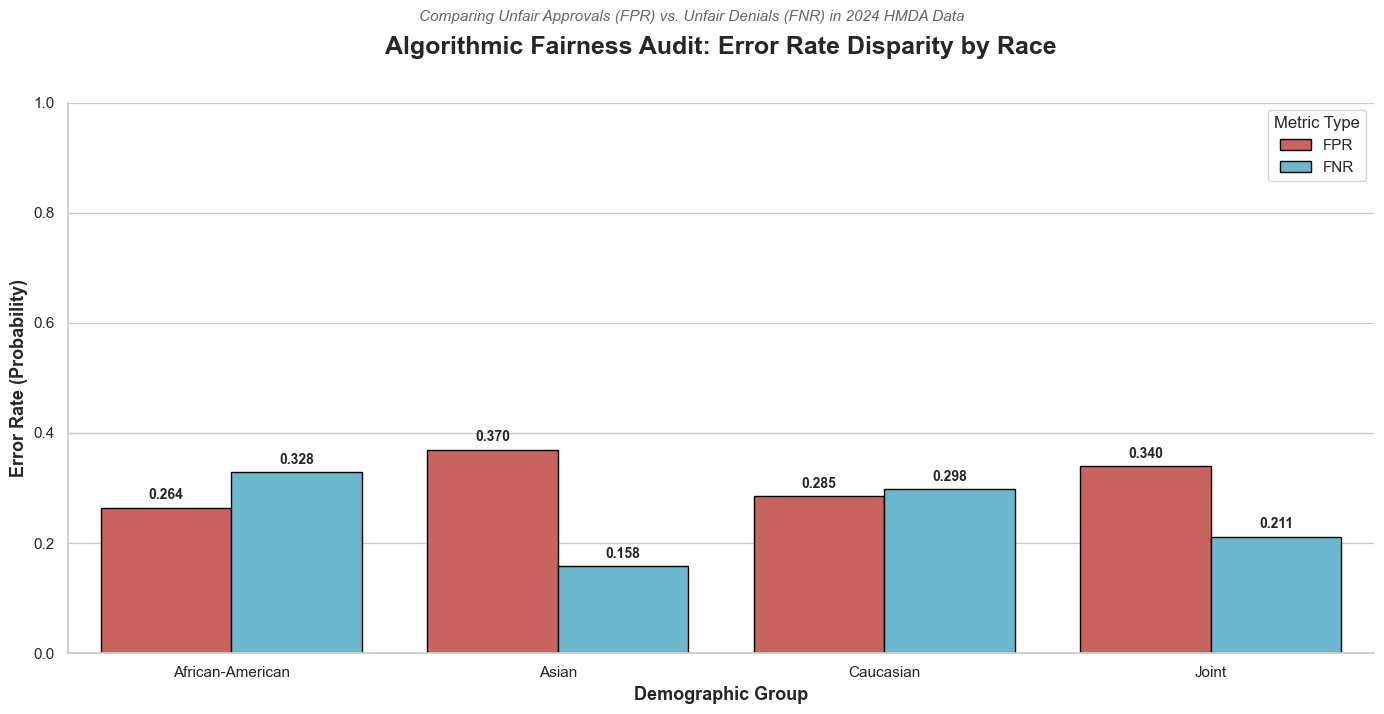

In [ ]:
# 1. Filter and Prepare HMDA Race Groups
# Ensure these labels match your 'er' dataframe from the previous step
plot_groups = ['African-American', 'Caucasian', 'Asian', 'Hispanic', 'Joint']
df_plot = er[er['race'].isin(plot_groups)].copy()

# Melt the dataframe for Seaborn grouping
df_melted = df_plot.melt(
    id_vars='race',
    value_vars=['FPR', 'FNR'],
    var_name='Metric',
    value_name='Rate'
)

# 2. Visual Style Setup
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 3. Create the Grouped Bar Chart
# Red (#d9534f) = FPR (Unfair Approval)
# Blue (#5bc0de) = FNR (Unfair Denial - The key metric for Disparate Impact)
ax = sns.barplot(
    data=df_melted,
    x='race',
    y='Rate',
    hue='Metric',
    palette=['#d9534f', '#5bc0de'],
    edgecolor='black'
)

# 4. Add Bar Annotations for Precision
for p in ax.patches:
    height = p.get_height()
    if height > 0.001: 
        ax.annotate(
            format(height, '.3f'),
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='center',
            xytext=(0, 9),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

# 5. Final Formatting for your MSBA Report
# 5. Final Formatting for your MSBA Report
# Increase pad to 35 to give room for the subtitle below it
plt.title('Algorithmic Fairness Audit: Error Rate Disparity by Race', 
          fontsize=18, fontweight='bold', pad=35)

# Set y to 0.94 and adjust fontsize for better hierarchy
plt.suptitle('Comparing Unfair Approvals (FPR) vs. Unfair Denials (FNR) in 2024 HMDA Data', 
             fontsize=11, y=0.92, style='italic', alpha=0.7)

plt.xlabel('Demographic Group', fontsize=13, fontweight='bold')
plt.ylabel('Error Rate (Probability)', fontsize=13, fontweight='bold')
plt.ylim(0, 1.0) # Expanded to 1.0 to ensure labels don't hit the top of the box
plt.legend(title='Metric Type', frameon=True, loc='upper right')

sns.despine()
# Use rect to ensure tight_layout doesn't override the suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

# Standardized Mean Difference

In [ ]:
def calculate_smd(data, group_col, score_col, ref_group):
    """Calculates Standardized Mean Difference (Cohen's d) relative to a reference group"""
    # 1. Get the reference group distribution (Caucasian)
    ref = data.loc[data[group_col] == ref_group, score_col]
    results = []
    
    # 2. Iterate through each race group to compare against the baseline
    for grp, g in data.groupby(group_col):
        if grp == ref_group:
            continue
            
        sc = g[score_col]
        
        # 3. Calculate Pooled Standard Deviation
        pooled_std = np.sqrt((ref.var() + sc.var()) / 2)
        
        # 4. Calculate Cohen's d (SMD)
        # d = (Mean_Group - Mean_Ref) / Pooled_Std
        d = ((sc.mean() - ref.mean()) / pooled_std if pooled_std > 0 else 0)
        
        # 5. Interpret Magnitude (Standard Cohen's d thresholds)
        abs_d = abs(d)
        mag = ('negligible' if abs_d < 0.2 else 
               'small' if abs_d < 0.5 else 
               'medium' if abs_d < 0.8 else 
               'large')
        
        results.append({
            group_col: grp,
            'mean_feature_val': round(sc.mean(), 3),
            'SMD': round(d, 3),
            'magnitude': mag
        })
        
    return pd.DataFrame(results)

# --- Run the Analysis ---
# We use 'loan_to_income_ratio' to see the "gap" in financial profiles
smd_tbl = calculate_smd(data, 'race', 'relative_income', ref_group='Caucasian')

print("── Standardized Mean Difference (SMD) by Race ────────────────────────")
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

── Standardized Mean Difference (SMD) by Race ────────────────────────
            race  mean_feature_val   SMD  magnitude
        Minority             6.843 0.008 negligible
           Asian             2.124 0.004 negligible
           Joint             1.858 0.003 negligible
African-American             2.083 0.001 negligible


# Intersectional Subgroup Analysis

In [ ]:
# 1. Calculate Approval Rates and Counts by Race and Gender
# We use observed=True to handle categorical data efficiently
sub_rates = (data.groupby(['race', 'gender'], observed=True)['target']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'approval_rate', 'count': 'n'})
             .reset_index())

# 2. Filter for statistical significance (n >= 30) 
# This ensures we aren't making claims based on tiny sample sizes
sub_rates = sub_rates[sub_rates['n'] >= 30].copy()

# 3. Set a MultiIndex to easily access the reference group (Caucasian Male)
sub_rates = sub_rates.set_index(['race', 'gender'])

# 4. Access the reference rate
# Caucasian Males are the industry standard baseline for Disparate Impact audits
try:
    ref_rate = sub_rates.loc[('Caucasian', 'Male'), 'approval_rate']

    # 5. Calculate AIR and Disparity Flags
    sub_rates['AIR'] = sub_rates['approval_rate'] / ref_rate
    sub_rates['ME'] = sub_rates['approval_rate'] - ref_rate # Marginal Effect
    sub_rates['flag_80'] = sub_rates['AIR'].apply(lambda x: '*** DISPARATE IMPACT' if x < 0.80 else '')

    # 6. Format and Display
    sub_rates_final = sub_rates.reset_index().sort_values('AIR')
    
    print("── Intersectional Fairness Audit: Race & Gender ─────────────────────")
    print(sub_rates_final.to_string(index=False, justify='left', col_space=10))

    # 7. Identify the group with the lowest AIR (Most Disadvantaged)
    worst_idx = sub_rates_final['AIR'].idxmin()
    worst = sub_rates_final.loc[worst_idx]
    
    print(f"\nMost Disadvantaged Group: {worst['race']} {worst['gender']}")
    print(f"Approval Rate: {worst['approval_rate']:.3%}")
    print(f"AIR relative to Caucasian Male: {worst['AIR']:.3f} (n={int(worst['n'])})")

except KeyError:
    print("Error: Reference group ('Caucasian', 'Male') not found in data.")
    print("Available Groups:", sub_rates.index.tolist())

── Intersectional Fairness Audit: Race & Gender ─────────────────────
race             gender      approval_rate  n          AIR        ME        flag_80   
        Minority Female     0.698210         27042    0.853719   -0.119635            
African-American   Male     0.705877        226728    0.863093   -0.111969            
African-American Female     0.708984        252711    0.866892   -0.108861            
        Minority   Male     0.714810         42484    0.874017   -0.103035            
African-American  Joint     0.750053        128307    0.917108   -0.067793            
        Minority  Joint     0.763795         15893    0.933912   -0.054050            
       Caucasian Female     0.812743       1089915    0.993762   -0.005102            
       Caucasian   Male     0.817845       1741596    1.000000    0.000000            
           Joint Female     0.830174          5064    1.015074    0.012329            
           Asian Female     0.838989         98596    1.0258

In [ ]:
# 1. Group by both Race and Gender for a "Double Disadvantage" check
intersectional_audit = (
    data.groupby(['race', 'gender'], observed=True)['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .reset_index()
)

# 2. Filter for groups with enough data to be statistically sound
intersectional_audit = intersectional_audit[intersectional_audit['n'] >= 50].copy()

# 3. Calculate AIR relative to the 'Caucasian Male' baseline
ref_rate = intersectional_audit.loc[
    (intersectional_audit['race'] == 'Caucasian') & 
    (intersectional_audit['gender'] == 'Male'), 'approval_rate'
].values[0]

intersectional_audit['AIR'] = intersectional_audit['approval_rate'] / ref_rate
intersectional_audit['flag'] = intersectional_audit['AIR'].apply(
    lambda x: '*** DISPARATE IMPACT' if x < 0.80 else ''
)

print("── FINAL INTERSECTIONAL AUDIT ──────────────────────────────────────")
print(intersectional_audit.sort_values('AIR').to_string(index=False))

── FINAL INTERSECTIONAL AUDIT ──────────────────────────────────────
            race gender  approval_rate       n      AIR flag
        Minority Female       0.698210   27042 0.853719     
African-American   Male       0.705877  226728 0.863093     
African-American Female       0.708984  252711 0.866892     
        Minority   Male       0.714810   42484 0.874017     
African-American  Joint       0.750053  128307 0.917108     
        Minority  Joint       0.763795   15893 0.933912     
       Caucasian Female       0.812743 1089915 0.993762     
       Caucasian   Male       0.817845 1741596 1.000000     
           Joint Female       0.830174    5064 1.015074     
           Asian Female       0.838989   98596 1.025854     
           Joint   Male       0.845327    5767 1.033602     
           Asian   Male       0.849098  199407 1.038213     
           Joint  Joint       0.852520  156340 1.042398     
       Caucasian  Joint       0.872663 2007921 1.067027     
           Asian

In [ ]:
# 1. Group by both Race and Gender for Intersectionality
intersectional_audit = (
    data.groupby(['race', 'gender'], observed=True)['target']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'approval_rate', 'count': 'n'})
    .reset_index()
)

# 2. Filter for statistical significance (n >= 50)
intersectional_audit = intersectional_audit[intersectional_audit['n'] >= 50].copy()

try:
    # 3. Calculate the Reference Rate (Caucasian Male)
    # We use .loc with a mask to find the specific baseline rate
    ref_mask = (intersectional_audit['race'] == 'Caucasian') & (intersectional_audit['gender'] == 'Male')
    ref_rate = intersectional_audit.loc[ref_mask, 'approval_rate'].values[0]

    # 4. Calculate AIR and Disparity Flags
    intersectional_audit['AIR'] = intersectional_audit['approval_rate'] / ref_rate
    intersectional_audit['ME'] = intersectional_audit['approval_rate'] - ref_rate
    intersectional_audit['flag_80'] = intersectional_audit['AIR'].apply(
        lambda x: '*** DISPARATE IMPACT' if x < 0.80 else ''
    )

    # 5. Print the Full Audit Table
    print("── FINAL INTERSECTIONAL AUDIT: RACE & GENDER ────────────────────────")
    print(intersectional_audit.sort_values('AIR').to_string(index=False, justify='left', col_space=12))

    # 6. Identify the Most Disadvantaged Group (Lowest AIR)
    # We find the row with the minimum AIR
    worst = intersectional_audit.loc[intersectional_audit['AIR'].idxmin()]

    print(f"\n{'='*60}")
    print(f"ANALYSIS SUMMARY")
    print(f"{'='*60}")
    print(f"Most Disadvantaged Group: {worst['race']} {worst['gender']}")
    print(f"Approval Rate           : {worst['approval_rate']:.3%}")
    print(f"AIR vs Caucasian Male   : {worst['AIR']:.3f} (n={int(worst['n'])})")
    
    if worst['AIR'] < 0.80:
        print(f"RESULT: This group falls below the 0.80 threshold for legal Disparate Impact.")
    else:
        print(f"RESULT: This group is above the 0.80 threshold but still shows a {abs(worst['ME']):.1%} gap.")

except (KeyError, IndexError):
    # If 'Caucasian' or 'Male' isn't in the data, list what is available
    print("\n[!] Error: Reference group ('Caucasian', 'Male') not found in filtered data.")
    print("Ensure you have applicants matching this criteria with n >= 50.")
    print("Available Groups in Data:")
    print(intersectional_audit[['race', 'gender']].drop_duplicates())

── FINAL INTERSECTIONAL AUDIT: RACE & GENDER ────────────────────────
race             gender        approval_rate  n            AIR          ME          flag_80     
        Minority Female       0.698210         27042      0.853719     -0.119635                
African-American   Male       0.705877        226728      0.863093     -0.111969                
African-American Female       0.708984        252711      0.866892     -0.108861                
        Minority   Male       0.714810         42484      0.874017     -0.103035                
African-American  Joint       0.750053        128307      0.917108     -0.067793                
        Minority  Joint       0.763795         15893      0.933912     -0.054050                
       Caucasian Female       0.812743       1089915      0.993762     -0.005102                
       Caucasian   Male       0.817845       1741596      1.000000      0.000000                
           Joint Female       0.830174          5064     

## Robustness Testing

### 1. Stress Testing via Data Perturbation (Dataset Drift)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def test_robustness_perturbation(model, X_test, y_test, feature_name, magnitude=0.1):
    """
    Simulates dataset drift by perturbing a specific feature and measuring performance drop.
    """
    X_perturbed = X_test.copy()
    
    # Apply a synthetic shift (e.g., a 10% decrease in reported income across the board)
    X_perturbed[feature_name] = X_perturbed[feature_name] * (1 - magnitude)
    
    # Get new predictions
    y_pred_orig = model.predict(X_test)
    y_pred_drift = model.predict(X_perturbed)
    
    # Calculate performance decay
    acc_orig = accuracy_score(y_test, y_pred_orig)
    acc_drift = accuracy_score(y_test, y_pred_drift)
    
    print(f"--- Robustness Test: {feature_name} Shift ({magnitude*100}%) ---")
    print(f"Original Accuracy: {acc_orig:.4f}")
    print(f"Drifted Accuracy:  {acc_drift:.4f}")
    print(f"Performance Drop:  {acc_orig - acc_drift:.4f}")

# Example usage for HMDA
test_robustness_perturbation(best_model, X_test, y_test, 'relative_income', magnitude=0.15)

--- Robustness Test: relative_income Shift (15.0%) ---
Original Accuracy: 0.7124
Drifted Accuracy:  0.6990
Performance Drop:  0.0133


### 2. Subgroup Stability (Invariance Testing)

In [ ]:
def check_subgroup_invariance(model, X_test, y_test, subgroup_col):
    """
    Checks if the model performance is invariant across different subgroups.
    Large variance suggests the model is overfit to specific demographics.
    """
    results = {}
    groups = X_test[subgroup_col].unique()
    
    for group in groups:
        idx = X_test[X_test[subgroup_col] == group].index
        if len(idx) > 50:  # Minimum sample size for reliability
            score = f1_score(y_test.loc[idx], model.predict(X_test.loc[idx]))
            results[group] = score
            
    f1_variance = np.var(list(results.values()))
    print(f"--- Subgroup Invariance: {subgroup_col} ---")
    for g, s in results.items():
        print(f"Group {g} F1-Score: {s:.4f}")
    print(f"Total Performance Variance: {f1_variance:.6f}")

# Check if model performs consistently across different loan purposes
check_subgroup_invariance(best_model, X_test, y_test, 'loan_purpose')

--- Subgroup Invariance: loan_purpose ---
Group 2 F1-Score: 0.4100
Group 31 F1-Score: 0.8134
Group 4 F1-Score: 0.2024
Group 1 F1-Score: 0.9414
Group 32 F1-Score: 0.6086
Group 5 F1-Score: 0.2692
Total Performance Variance: 0.074134
